<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Sionna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 54.3 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found exis

In [1]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [2]:
# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

Modules Imported Successfully


In [3]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 0 1 0 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 1], shape=(20,), dtype=int32)


In [4]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1. -1.  1. -1. -1. -1.  1.  1. -1.  1. -1. -1.  1. -1. -1. -1.  1. -1.
  1.  1.], shape=(20,), dtype=float32)


In [5]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [6]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [7]:
print(ber)

[np.float64(0.0768), np.float64(0.0382), np.float64(0.0137), np.float64(0.0019), np.float64(0.0003), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


In [8]:
len(ber)

11

In [9]:
SNR_dB = np.arange(0,21,2)

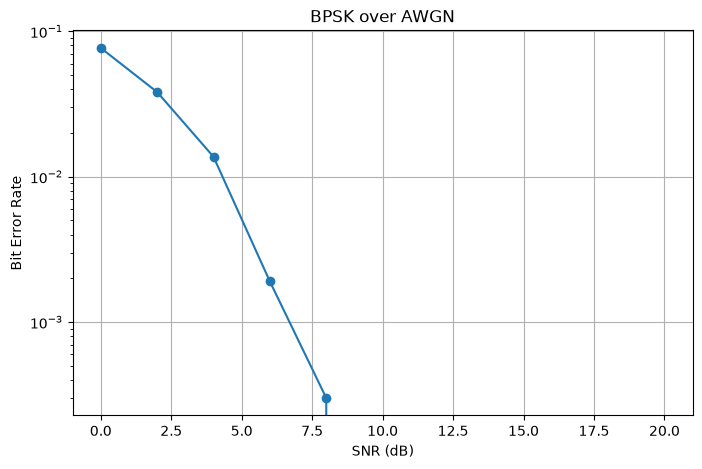

In [10]:
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
import sionna

print(dir(sionna))

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']


In [13]:
print("Sionna Version:", sionna.__version__)

Sionna Version: 2.0.1


In [14]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [15]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [16]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [17]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [18]:
import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

['BaseChannelEstimator', 'BaseChannelInterpolator', 'CBFPrecodedChannel', 'EPDetector', 'EmptyPilotPattern', 'EyePrecodedChannel', 'KBestDetector', 'KroneckerPilotPattern', 'LMMSEEqualizer', 'LMMSEInterpolator', 'LMMSEInterpolator1D', 'LMMSEPostEqualizationSINR', 'LSChannelEstimator', 'LinearDetector', 'LinearInterpolator', 'MFEqualizer', 'MMSEPICDetector', 'MaximumLikelihoodDetector', 'MaximumLikelihoodDetectorWithPrior', 'NearestNeighborInterpolator', 'OFDMDemodulator', 'OFDMDetector', 'OFDMDetectorWithPrior', 'OFDMEqualizer', 'OFDMModulator', 'PilotPattern', 'PostEqualizationSINR', 'PrecodedChannel', 'RZFPrecodedChannel', 'RZFPrecoder', 'RemoveNulledSubcarriers', 'ResourceGrid', 'ResourceGridDemapper', 'ResourceGridMapper', 'SpatialChannelFilter', 'ZFEqualizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'channel_estimation', 'demodulator', 'detection', 'equalization', 'modulator', 'pilot_pattern', 'precoding

In [19]:
import sionna.phy.channel as ch

print(dir(ch))

['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [20]:
import sionna.phy.ofdm as ofdm

print(dir(ofdm))

['BaseChannelEstimator', 'BaseChannelInterpolator', 'CBFPrecodedChannel', 'EPDetector', 'EmptyPilotPattern', 'EyePrecodedChannel', 'KBestDetector', 'KroneckerPilotPattern', 'LMMSEEqualizer', 'LMMSEInterpolator', 'LMMSEInterpolator1D', 'LMMSEPostEqualizationSINR', 'LSChannelEstimator', 'LinearDetector', 'LinearInterpolator', 'MFEqualizer', 'MMSEPICDetector', 'MaximumLikelihoodDetector', 'MaximumLikelihoodDetectorWithPrior', 'NearestNeighborInterpolator', 'OFDMDemodulator', 'OFDMDetector', 'OFDMDetectorWithPrior', 'OFDMEqualizer', 'OFDMModulator', 'PilotPattern', 'PostEqualizationSINR', 'PrecodedChannel', 'RZFPrecodedChannel', 'RZFPrecoder', 'RemoveNulledSubcarriers', 'ResourceGrid', 'ResourceGridDemapper', 'ResourceGridMapper', 'SpatialChannelFilter', 'ZFEqualizer', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'channel_estimation', 'demodulator', 'detection', 'equalization', 'modulator', 'pilot_pattern', 'precoding

In [21]:
import numpy as np

np.random.seed(42)

num_users = 30

# User locations (meters)
user_positions = np.random.uniform(
    low=0,
    high=500,
    size=(num_users,2)
)

print(user_positions)

[[187.27005942 475.3571532 ]
 [365.99697091 299.3292421 ]
 [ 78.00932022  77.99726017]
 [ 29.04180608 433.08807289]
 [300.55750587 354.0362889 ]
 [ 10.29224715 484.95492608]
 [416.2213204  106.16955534]
 [ 90.9124836   91.70225493]
 [152.12112148 262.37821582]
 [215.97250932 145.6145701 ]
 [305.92644736  69.74693033]
 [146.07232427 183.18092165]
 [228.03499211 392.5879807 ]
 [ 99.83689108 257.11721921]
 [296.20728443  23.22520636]
 [303.77242595  85.26206184]
 [ 32.52579649 474.44276863]
 [482.81601654 404.19867406]
 [152.30688459  48.836057  ]
 [342.11651326 220.07624687]
 [ 61.01911742 247.58845506]
 [ 17.19426056 454.66020104]
 [129.3899908  331.26114218]
 [155.85553804 260.03401059]
 [273.35513967  92.42722776]
 [484.79231388 387.56641168]
 [469.74947078 447.41367521]
 [298.94998941 460.93711751]
 [ 44.24625103  97.99143121]
 [ 22.61364446 162.66516538]]


In [22]:
bs_positions = np.array([
    [100,100],
    [250,400],
    [450,200]
])

print(bs_positions)
num_users = len(user_positions)

[[100 100]
 [250 400]
 [450 200]]


In [23]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [25]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [26]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250746 0.9906148  2.9736955  0.7308684
 0.2100257  0.14564277 1.5338103  1.0039163 ]


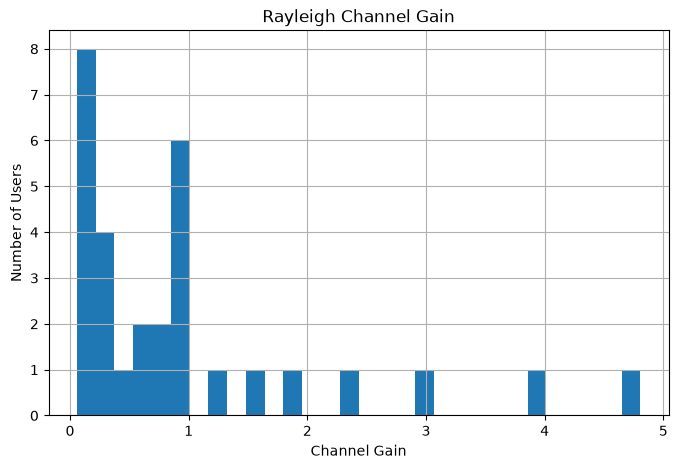

In [27]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()